# Assignment 2: From Trees to Neural Networks
Using the Bank Marketing Dataset

In [1]:
# Install xgboost if not already available
!pip install xgboost --quiet

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve
)
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
from xgboost import plot_importance

random.seed(42)
np.random.seed(42)

## Loading data

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
!wget -q {url} -O bank.zip && unzip -q bank.zip

In [4]:
df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=";")
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [7]:
# no nulls but there are "unknown" strings acting as missing values
for col in df.columns:
    u = (df[col] == 'unknown').sum()
    if u > 0:
        print(f"{col}: {u} unknowns")

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns


In [8]:
# checking class balance
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [9]:
round(df['y'].value_counts(normalize=True) * 100, 2)

,proportion
y,
no,88.73
yes,11.27


## Data Preparation & Feature Engineering

In [10]:
# encode target first
df['y'] = (df['y'] == 'yes').astype(int)

In [11]:
# keeping "unknown" as its own category rather than imputing
# since not answering is probably informative on its own

# new features:
# pdays=999 means never contacted before, so flagging that
df['prev_contact'] = (df['pdays'] != 999).astype(int)

# combining campaign + previous into one "total outreach" feature
df['total_contacts'] = df['campaign'] + df['previous']

# age buckets - raw age probably isn't linear w/ subscription behavior
df['age_bucket'] = pd.cut(df['age'], bins=[0,30,45,60,100],
                           labels=['young','mid','senior','old'])

In [12]:
df[['prev_contact','total_contacts','age_bucket']].head(10)

,prev_contact,total_contacts,age_bucket
0,0,1,senior
1,0,1,senior
2,0,1,mid
3,0,1,mid
4,0,1,senior
5,0,1,mid
6,0,1,senior
7,0,1,mid
8,0,1,young
9,0,1,young


In [13]:
# figure out which columns need categorical encoding after feature engineering
feature_cols = [c for c in df.columns if c != 'y']
X_raw = df[feature_cols].copy()
y = df['y'].copy()

cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

print(cat_cols)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_bucket']


In [14]:
# 70/15/15 split first so encoding is fit on train only
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

(28829, 23) (6180, 23) (6179, 23)


In [15]:
# one-hot encode categorical columns using the training split only
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = ohe.fit_transform(X_train_raw[cat_cols])
X_val_cat = ohe.transform(X_val_raw[cat_cols])
X_test_cat = ohe.transform(X_test_raw[cat_cols])

cat_feature_names = ohe.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train_raw.index)
X_val_cat = pd.DataFrame(X_val_cat, columns=cat_feature_names, index=X_val_raw.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_feature_names, index=X_test_raw.index)

X_train = pd.concat([X_train_raw[num_cols], X_train_cat], axis=1)
X_val = pd.concat([X_val_raw[num_cols], X_val_cat], axis=1)
X_test = pd.concat([X_test_raw[num_cols], X_test_cat], axis=1)

print(X_train.shape, X_val.shape, X_test.shape)

(28829, 58) (6180, 58) (6179, 58)


In [16]:
print(y_train.mean().round(3), y_val.mean().round(3), y_test.mean().round(3))

0.113 0.113 0.113


In [17]:
# scaling for mlp only - trees don't care about scale but neural nets do
# fitting only on train to avoid leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

## XGBoost

In [18]:
# quick baseline before touching anything
xgb_base = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                               max_depth=4, eval_metric='logloss',
                               random_state=42)

xgb_base.fit(X_train, y_train,
             eval_set=[(X_train, y_train),(X_val, y_val)],
             verbose=False)

print("val acc:", round(accuracy_score(y_val, xgb_base.predict(X_val)), 4))
print("val f1:", round(f1_score(y_val, xgb_base.predict(X_val)), 4))
# acc looks decent at 0.91 but f1 of 0.57 shows it's struggling with the minority class

val acc: 0.9152
val f1: 0.5788


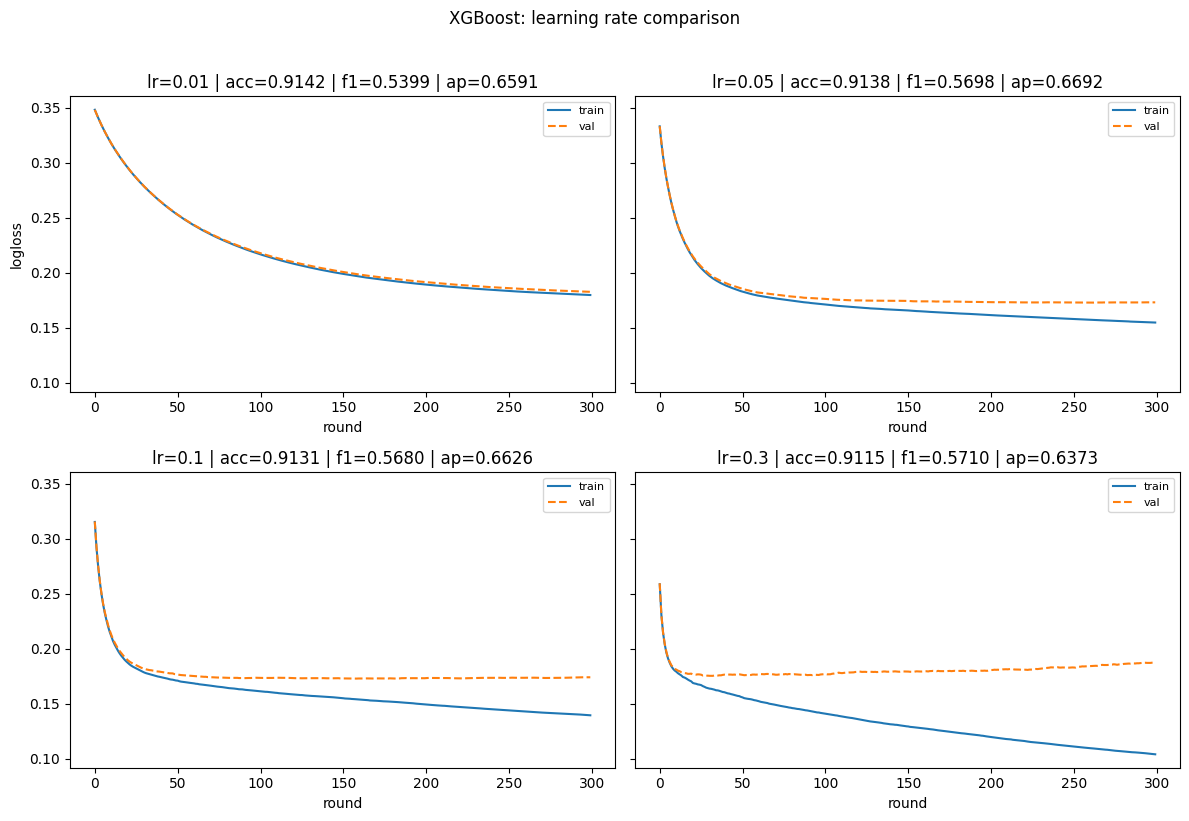

,accuracy,f1,auc_pr
0.01,0.914239,0.539931,0.659069
0.05,0.913754,0.569814,0.669212
0.10,0.913107,0.567981,0.662596
0.30,0.911489,0.570980,0.637254


In [19]:
# effect of learning rate
lrs = [0.01, 0.05, 0.1, 0.3]
lr_res = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for i, lr in enumerate(lrs):
    m = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=lr,
        max_depth=4,
        subsample=0.8,
        eval_metric='logloss',
        random_state=42
    )
    m.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    res = m.evals_result()
    tr = res['validation_0']['logloss']
    va = res['validation_1']['logloss']

    y_val_pred = m.predict(X_val)
    y_val_prob = m.predict_proba(X_val)[:, 1]
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    ap = average_precision_score(y_val, y_val_prob)

    lr_res[lr] = {'model': m, 'acc': acc, 'f1': f1, 'auc_pr': ap}

    axes[i].plot(tr, label='train')
    axes[i].plot(va, label='val', linestyle='--')
    axes[i].set_title(f'lr={lr} | acc={acc:.4f} | f1={f1:.4f} | ap={ap:.4f}')
    axes[i].set_xlabel('round')
    if i == 0:
        axes[i].set_ylabel('logloss')
    axes[i].legend(fontsize=8)

plt.suptitle('XGBoost: learning rate comparison', y=1.02)
plt.tight_layout()
plt.savefig('xgb_lr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame(
    {
        lr: {'accuracy': v['acc'], 'f1': v['f1'], 'auc_pr': v['auc_pr']}
        for lr, v in lr_res.items()
    }
).T.sort_index()

In [20]:
# lr=0.01 - train and val stay close, but validation loss is still drifting down at round 300, so it likely needs more trees
# lr=0.05 - smoother convergence and the strongest validation AUC-PR among the tested rates, so it is a reasonable final choice
# lr=0.1 - converges faster but gives up a bit of AUC-PR relative to 0.05
# lr=0.3 - pushes F1 up slightly, but the validation curve turns upward earlier and AUC-PR drops, so overfitting is more obvious
# all four land around 0.91 accuracy, which is why F1 and AUC-PR are more useful here than accuracy alone


In [21]:
# how does tree depth affect overfitting?
depths = [3, 5, 7]
for d in depths:
    m = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=d,
        eval_metric='logloss',
        random_state=42
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = m.predict(X_val)
    y_val_prob = m.predict_proba(X_val)[:, 1]

    acc = round(accuracy_score(y_val, y_val_pred), 4)
    f1 = round(f1_score(y_val, y_val_pred), 4)
    ap = round(average_precision_score(y_val, y_val_prob), 4)

    print(f"max_depth={d}: acc={acc}, f1={f1}, auc_pr={ap}")

max_depth=3: acc=0.9147, f1=0.5619, auc_pr=0.6678
max_depth=5: acc=0.9142, f1=0.5774, auc_pr=0.6621
max_depth=7: acc=0.9134, f1=0.5797, auc_pr=0.6589


In [22]:
# checking how many trees we actually need
estimator_counts = [50, 100, 200, 500]
for n in estimator_counts:
    m = xgb.XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=4,
        eval_metric='logloss',
        random_state=42
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = m.predict(X_val)
    y_val_prob = m.predict_proba(X_val)[:, 1]

    acc = round(accuracy_score(y_val, y_val_pred), 4)
    f1 = round(f1_score(y_val, y_val_pred), 4)
    ap = round(average_precision_score(y_val, y_val_prob), 4)

    print(f"n_estimators={n}: acc={acc}, f1={f1}, auc_pr={ap}")

# this is why we use early stopping in the final model - no need to guess

n_estimators=50: acc=0.9144, f1=0.5617, auc_pr=0.6668
n_estimators=100: acc=0.9162, f1=0.5754, auc_pr=0.6683
n_estimators=200: acc=0.9152, f1=0.5788, auc_pr=0.6671
n_estimators=500: acc=0.915, f1=0.5837, auc_pr=0.6564


In [23]:
# subsample controls what fraction of training rows each tree sees
# lower = more regularization, less overfitting but higher bias
for ss in [0.5, 0.8, 1.0]:
    m = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=ss,
        eval_metric='logloss',
        random_state=42
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = m.predict(X_val)
    y_val_prob = m.predict_proba(X_val)[:, 1]

    acc = round(accuracy_score(y_val, y_val_pred), 4)
    f1 = round(f1_score(y_val, y_val_pred), 4)
    ap = round(average_precision_score(y_val, y_val_prob), 4)

    print(f"subsample={ss}: acc={acc}, f1={f1}, auc_pr={ap}")

subsample=0.5: acc=0.9102, f1=0.5513, auc_pr=0.6552
subsample=0.8: acc=0.9134, f1=0.5703, auc_pr=0.6647
subsample=1.0: acc=0.9152, f1=0.5788, auc_pr=0.6671


In [24]:
# reg_alpha = L1 (drives small weights to zero, feature selection-like)
# reg_lambda = L2 (shrinks all weights, more stable)
reg_configs = [
    (0, 1),      # default - no L1, light L2
    (0.1, 1.0),  # light L1 + L2
    (0.5, 1.0),  # stronger L1
    (0.1, 5.0),  # stronger L2
]

for alpha, lam in reg_configs:
    m = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        reg_alpha=alpha,
        reg_lambda=lam,
        eval_metric='logloss',
        random_state=42
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = m.predict(X_val)
    y_val_prob = m.predict_proba(X_val)[:, 1]

    acc = round(accuracy_score(y_val, y_val_pred), 4)
    f1 = round(f1_score(y_val, y_val_pred), 4)
    ap = round(average_precision_score(y_val, y_val_prob), 4)

    print(f"alpha={alpha}, lambda={lam}: acc={acc}, f1={f1}, auc_pr={ap}")

alpha=0, lambda=1: acc=0.9152, f1=0.5788, auc_pr=0.6671
alpha=0.1, lambda=1.0: acc=0.9146, f1=0.5714, auc_pr=0.6684
alpha=0.5, lambda=1.0: acc=0.9141, f1=0.5693, auc_pr=0.6666
alpha=0.1, lambda=5.0: acc=0.915, f1=0.5776, auc_pr=0.6688


In [25]:
# based on the sweeps above, keep the final model aligned with the tested settings:
# lr=0.05 is explicitly tested above and gives the best validation AUC-PR among the learning-rate candidates
# max_depth=5 is kept as a compromise between depth 3's slightly better AUC-PR and depth 7's slightly better F1
# n_estimators=1000 with early stopping lets the model stop itself instead of hard-coding a round count
# the subsample / regularization settings should be described as reasonable regularized choices, not as the single best sweep winners


In [26]:
xgb_final = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

xgb_val_pred = xgb_final.predict(X_val)
xgb_val_prob = xgb_final.predict_proba(X_val)[:, 1]

print("best iter:", xgb_final.best_iteration)
print("val acc:", round(accuracy_score(y_val, xgb_val_pred), 4))
print("val f1:", round(f1_score(y_val, xgb_val_pred), 4))
print("val auc_pr:", round(average_precision_score(y_val, xgb_val_prob), 4))

best iter: 223
val acc: 0.9146
val f1: 0.5735
val auc_pr: 0.6664


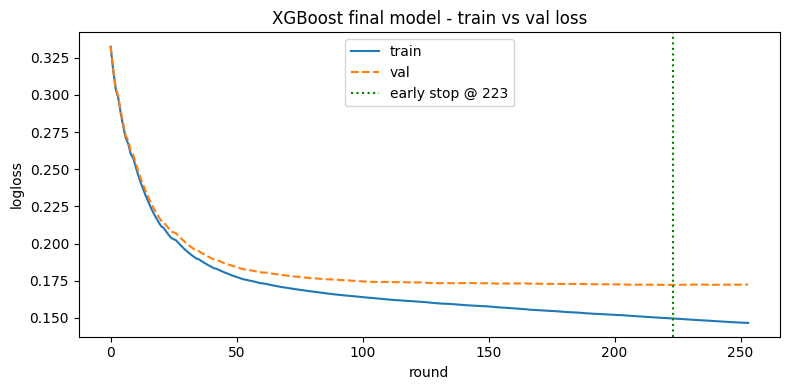

In [27]:
evals = xgb_final.evals_result()

plt.figure(figsize=(8,4))
plt.plot(evals['validation_0']['logloss'], label='train')
plt.plot(evals['validation_1']['logloss'], label='val', linestyle='--')
plt.axvline(xgb_final.best_iteration, color='green', linestyle=':',
            label=f'early stop @ {xgb_final.best_iteration}')
plt.xlabel('round')
plt.ylabel('logloss')
plt.title('XGBoost final model - train vs val loss')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_final_loss.png', dpi=150, bbox_inches='tight')
plt.show()

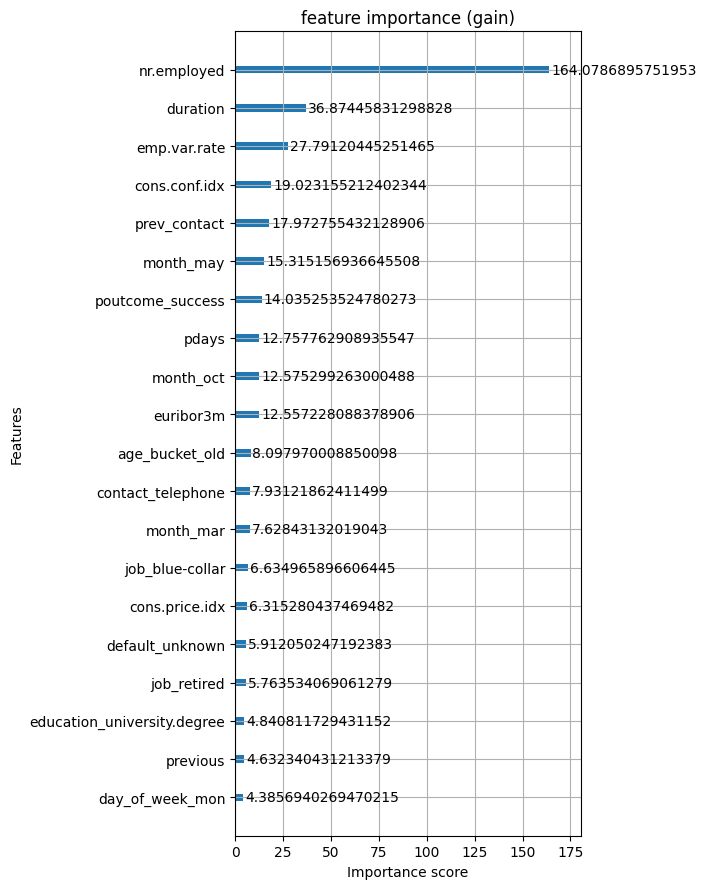

In [28]:
fig, ax = plt.subplots(figsize=(7,9))
plot_importance(xgb_final, ax=ax, max_num_features=20,
                importance_type='gain', title='feature importance (gain)')
plt.tight_layout()
plt.savefig('xgb_feat_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## MLP

In [29]:
# baseline
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)
mlp_base.fit(X_train_sc, y_train)

mlp_base_pred = mlp_base.predict(X_val_sc)
mlp_base_prob = mlp_base.predict_proba(X_val_sc)[:, 1]

print("val acc:", round(accuracy_score(y_val, mlp_base_pred), 4))
print("val f1:", round(f1_score(y_val, mlp_base_pred), 4))
print("val auc_pr:", round(average_precision_score(y_val, mlp_base_prob), 4))

val acc: 0.8963
val f1: 0.5148
val auc_pr: 0.5544


In [30]:
# trying different architectures
archs = {
    '(64,)': (64,),
    '(128,64)': (128,64),
    '(256,128,64)': (256,128,64)
}

arch_res = {}
for name, arch in archs.items():
    m = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )
    m.fit(X_train_sc, y_train)

    y_val_pred = m.predict(X_val_sc)
    y_val_prob = m.predict_proba(X_val_sc)[:, 1]

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    ap = average_precision_score(y_val, y_val_prob)

    arch_res[name] = {'model': m, 'acc': acc, 'f1': f1, 'auc_pr': ap}
    print(f"{name}: acc={acc:.4f}, f1={f1:.4f}, auc_pr={ap:.4f}, iters={m.n_iter_}")

(64,): acc=0.8963, f1=0.5148, auc_pr=0.5544, iters=300
(128,64): acc=0.8905, f1=0.4967, auc_pr=0.5088, iters=160
(256,128,64): acc=0.8940, f1=0.5271, auc_pr=0.5502, iters=122


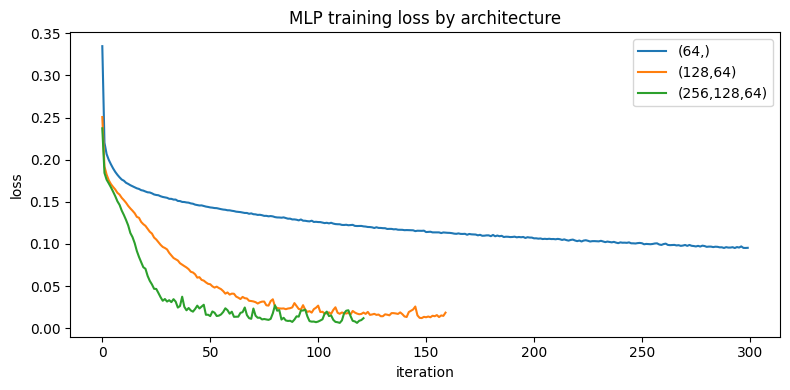

In [31]:
plt.figure(figsize=(8,4))
for name, res in arch_res.items():
    plt.plot(res['model'].loss_curve_, label=name)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('MLP training loss by architecture')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_arch_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# compare architectures using F1 / AUC-PR and convergence behavior, not accuracy alone
# among the tested relu models, (64,) is actually the strongest on validation accuracy / AUC-PR,
# while (256,128,64) gives the best F1
# (128,64) is still usable as a middle-ground architecture for the activation comparison,
# but the report should not describe it as the clear best architecture overall


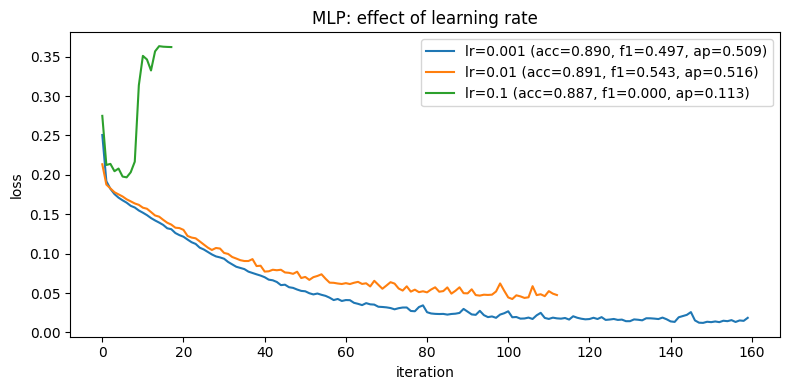

In [33]:
# now checking learning rate sensitivity
plt.figure(figsize=(8,4))
for lr in [0.001, 0.01, 0.1]:
    m = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    m.fit(X_train_sc, y_train)

    y_val_pred = m.predict(X_val_sc)
    y_val_prob = m.predict_proba(X_val_sc)[:, 1]

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    ap = average_precision_score(y_val, y_val_prob)

    plt.plot(m.loss_curve_, label=f'lr={lr} (acc={acc:.3f}, f1={f1:.3f}, ap={ap:.3f})')

plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('MLP: effect of learning rate')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_lr_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# does training longer actually help?
for iters in [100, 200, 500]:
    m = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=iters,
        random_state=42
    )
    m.fit(X_train_sc, y_train)

    y_val_pred = m.predict(X_val_sc)
    y_val_prob = m.predict_proba(X_val_sc)[:, 1]

    acc = round(accuracy_score(y_val, y_val_pred), 4)
    f1 = round(f1_score(y_val, y_val_pred), 4)
    ap = round(average_precision_score(y_val, y_val_prob), 4)

    print(
        f"max_iter={iters}: acc={acc}, f1={f1}, auc_pr={ap}, "
        f"converged={m.n_iter_ < iters}, iters_run={m.n_iter_}"
    )

# if the model converges before max_iter it doesn't matter how high you set it

max_iter=100: acc=0.8911, f1=0.5077, auc_pr=0.5192, converged=False, iters_run=100
max_iter=200: acc=0.8905, f1=0.4967, auc_pr=0.5088, converged=True, iters_run=160
max_iter=500: acc=0.8905, f1=0.4967, auc_pr=0.5088, converged=True, iters_run=160


In [35]:
# relu vs tanh
for act in ['relu', 'tanh']:
    m = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation=act,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )
    m.fit(X_train_sc, y_train)

    y_val_pred = m.predict(X_val_sc)
    y_val_prob = m.predict_proba(X_val_sc)[:, 1]

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    ap = average_precision_score(y_val, y_val_prob)

    print(f"{act}: acc={acc:.4f}, f1={f1:.4f}, auc_pr={ap:.4f}")

relu: acc=0.8905, f1=0.4967, auc_pr=0.5088
tanh: acc=0.8956, f1=0.5057, auc_pr=0.5401


In [36]:
# max_iter=500 is enough once the convergence check above says the model settles early
# keep the final MLP consistent everywhere in the notebook:
# hidden_layer_sizes=(128,64), learning_rate_init=0.001, activation='tanh'
# in the writeup, present this as the chosen final architecture for comparison, not as the best-tested architecture overall


In [37]:
# tanh is clearly better than relu for the chosen (128,64) architecture on validation accuracy, F1, and AUC-PR
mlp_final = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='tanh',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)
mlp_final.fit(X_train_sc, y_train)

mlp_val_pred = mlp_final.predict(X_val_sc)
mlp_val_prob = mlp_final.predict_proba(X_val_sc)[:, 1]

print("val acc:", round(accuracy_score(y_val, mlp_val_pred), 4))
print("val f1:", round(f1_score(y_val, mlp_val_pred), 4))
print("val auc_pr:", round(average_precision_score(y_val, mlp_val_prob), 4))


val acc: 0.8956
val f1: 0.5057
val auc_pr: 0.5401


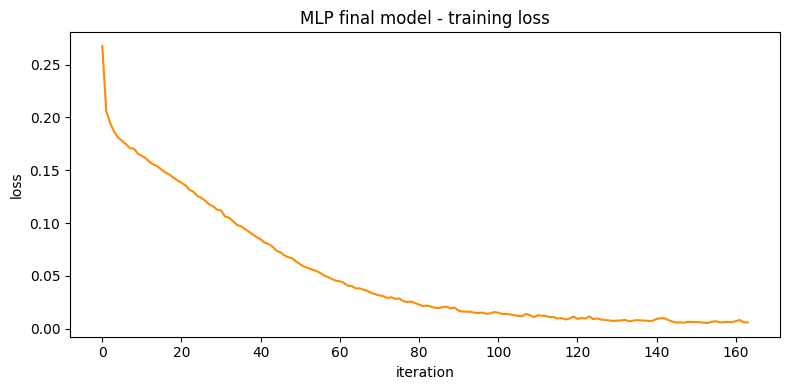

In [38]:
plt.figure(figsize=(8,4))
plt.plot(mlp_final.loss_curve_, color='darkorange')
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('MLP final model - training loss')
plt.tight_layout()
plt.savefig('mlp_final_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison

In [39]:
# retraining both on fixed settings for fair time comparison
t0 = time.time()
xgb_t = xgb.XGBClassifier(
    n_estimators=xgb_final.best_iteration + 1,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42
)
xgb_t.fit(X_train, y_train)
xgb_time = time.time() - t0

t0 = time.time()
mlp_t = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='tanh',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)
mlp_t.fit(X_train_sc, y_train)
mlp_time = time.time() - t0

print(f"xgb: {xgb_time:.2f}s | mlp: {mlp_time:.2f}s")

xgb: 1.23s | mlp: 150.48s


In [41]:
def get_metrics(name, model, X, y_true):
    yp = model.predict(X)
    yprob = model.predict_proba(X)[:,1]
    return {
        'model': name,
        'accuracy':  round(accuracy_score(y_true, yp), 4),
        'precision': round(precision_score(y_true, yp), 4),
        'recall':    round(recall_score(y_true, yp), 4),
        'f1':        round(f1_score(y_true, yp), 4),
        'auc_pr':    round(average_precision_score(y_true, yprob), 4),
        'roc_auc':   round(roc_auc_score(y_true, yprob), 4)
    }

xgb_m = get_metrics('XGBoost', xgb_t, X_test, y_test)
mlp_m = get_metrics('MLP', mlp_t, X_test_sc, y_test)

pd.DataFrame([xgb_m, mlp_m]).set_index('model')

,accuracy,precision,recall,f1,auc_pr,roc_auc
model,,,,,,
XGBoost,0.9204,0.6809,0.5517,0.6095,0.6969,0.9553
MLP,0.9042,0.5841,0.5187,0.5495,0.5683,0.9218


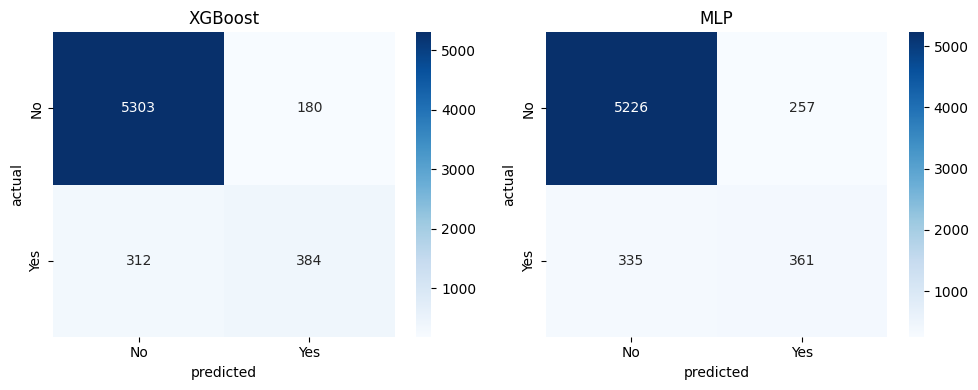

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, (name, model, X) in zip(axes, [('XGBoost', xgb_t, X_test),
                                         ('MLP', mlp_t, X_test_sc)]):
    cm = confusion_matrix(y_test, model.predict(X))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(name)
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

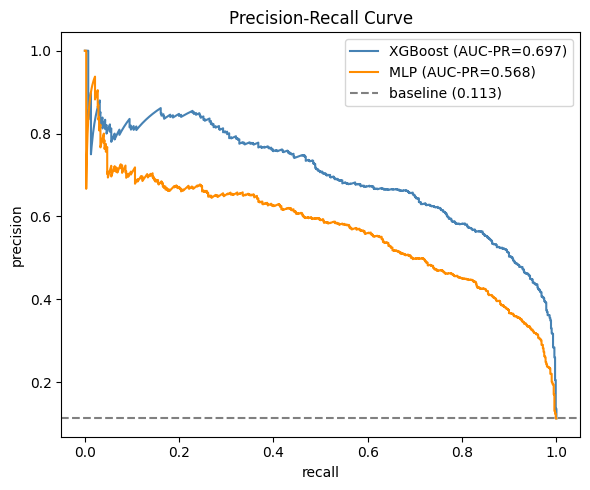

In [43]:
fig, ax = plt.subplots(figsize=(6,5))

for name, model, X, c in [('XGBoost', xgb_t, X_test, 'steelblue'),
                            ('MLP', mlp_t, X_test_sc, 'darkorange')]:
    prob = model.predict_proba(X)[:,1]
    p, r, _ = precision_recall_curve(y_test, prob)
    aucpr = average_precision_score(y_test, prob)
    ax.plot(r, p, label=f'{name} (AUC-PR={aucpr:.3f})', color=c)

ax.axhline(y_test.mean(), linestyle='--', color='gray',
           label=f'baseline ({y_test.mean():.3f})')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## AI Tool Usage Disclosure

I used AI tools to assist with this assignment in the following ways:
- Assignment setup (imports, data loading)
- Help with pandas/sklearn syntax and debugging
- Suggestions on how to structure matplotlib plots
- Clarifying XGBoost early stopping API usage
- Consistency checks between the notebook and the written report

All modeling decisions (feature engineering choices, hyperparameter ranges to explore, interpretation of results) and all written analysis in the report are my own. I ran all code myself and verified the outputs.